In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [19]:
# Replace with your actual file path
df = pd.read_csv(r"/dating_app_behavior_dataset.csv")
df.head()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [20]:
# Check for missing values
print(df.isnull().sum())

# Basic info
print(df.info())

# Fill or drop missing values if needed
df = df.dropna()  # or use df.fillna(method='ffill') etc.


gender                  0
sexual_orientation      0
location_type           0
income_bracket          0
education_level         0
interest_tags           0
app_usage_time_min      0
app_usage_time_label    0
swipe_right_ratio       0
swipe_right_label       0
likes_received          0
mutual_matches          0
profile_pics_count      0
bio_length              0
message_sent_count      0
emoji_usage_rate        0
last_active_hour        0
swipe_time_of_day       0
match_outcome           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         

In [21]:
# Automatically encode all object (categorical) columns
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [30]:
# Define features and target (assuming 'match_outcome' is the target)
X = df.drop('match_outcome', axis=1)
y = df['match_outcome']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)


[[115 134  91  91 107 107  85 108 111  66]
 [117 129 103 104  80 118  99  99 103  75]
 [101 128 125  94  93 104  91  97  87  78]
 [131 135 117  81 100  98  94  81  85  78]
 [124  99  98 109 110  83  96  89  88  73]
 [131 123 108 104  98 104  98 103  87  65]
 [117  99 126  95 119  78 111  95  97  74]
 [124  98 114  84 101  98  92  93  84  68]
 [135 118 100 111 100 116  79  90  86  73]
 [101 124 101  92  80 120  92 107 109  69]]
              precision    recall  f1-score   support

           0       0.10      0.11      0.10      1015
           1       0.11      0.13      0.12      1027
           2       0.12      0.13      0.12       998
           3       0.08      0.08      0.08      1000
           4       0.11      0.11      0.11       969
           5       0.10      0.10      0.10      1021
           6       0.12      0.11      0.11      1011
           7       0.10      0.10      0.10       956
           8       0.09      0.09      0.09      1008
           9       0.10     

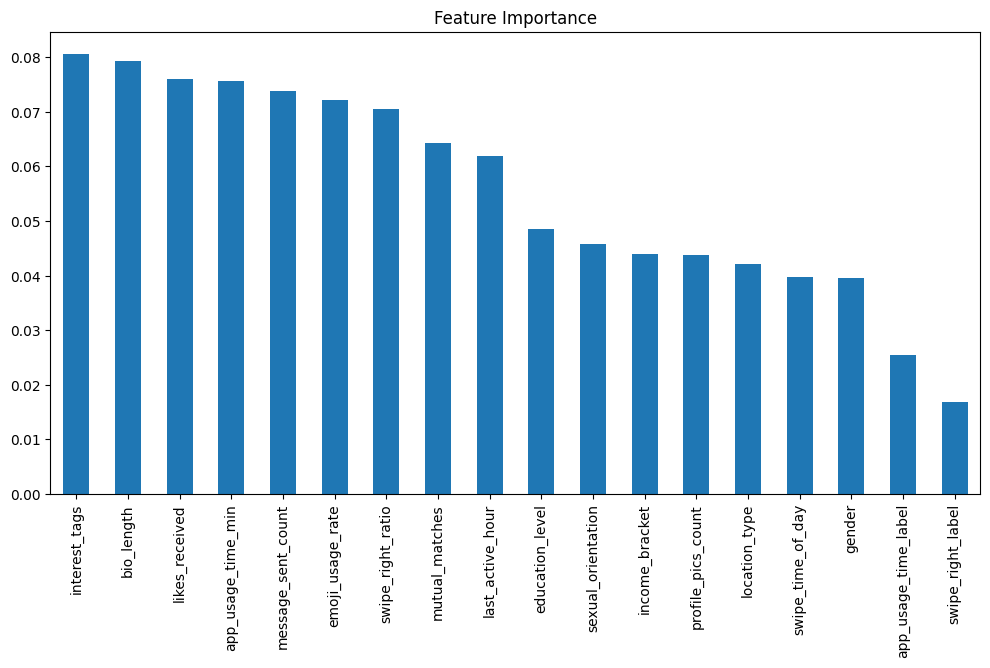

In [29]:
# Evaluation metrics
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Feature importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6))
plt.title("Feature Importance")
plt.show()


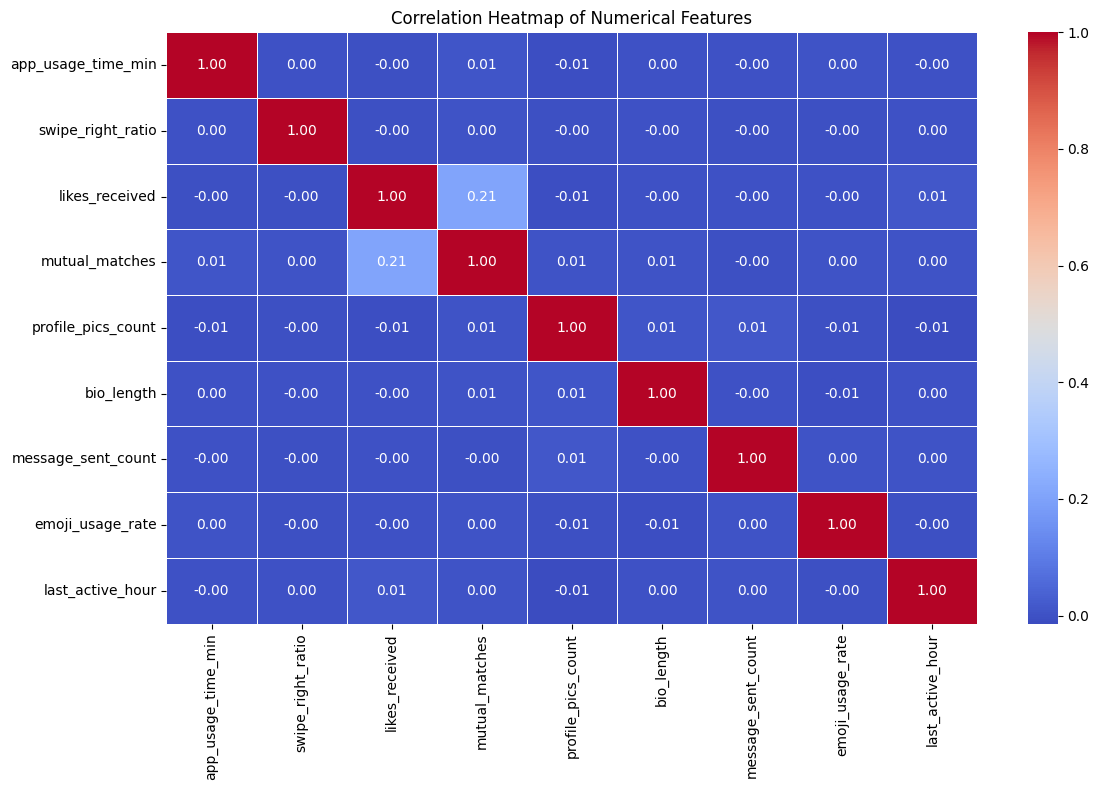

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("/dating_app_behavior_dataset.csv")

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


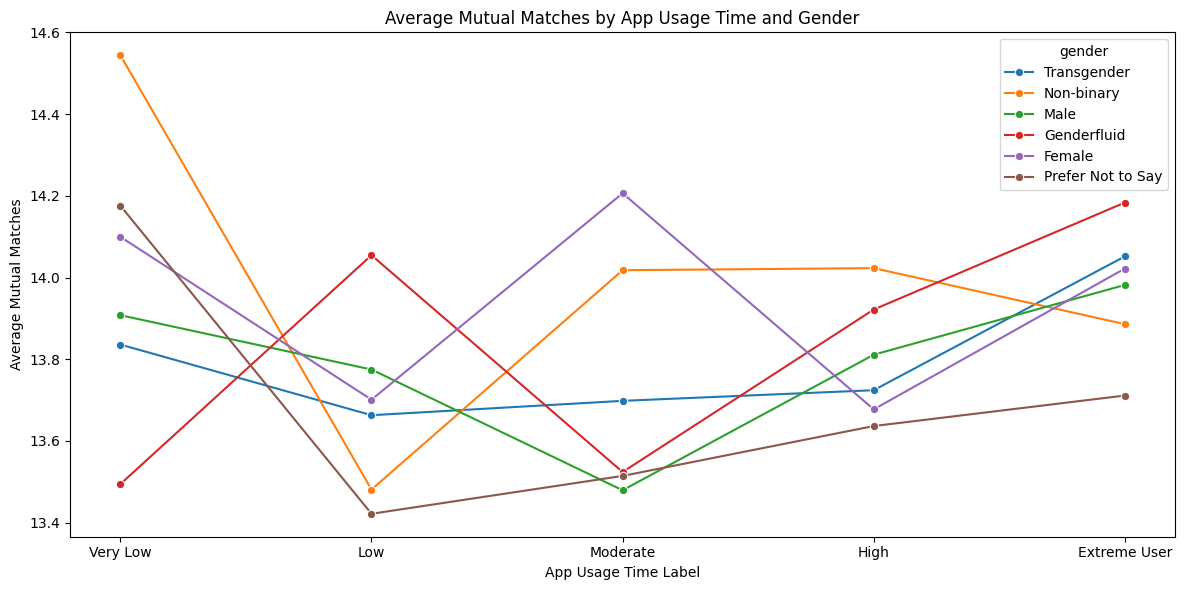

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by app usage time label and gender, then calculate average mutual matches
grouped = df.groupby(['app_usage_time_label', 'gender'])['mutual_matches'].mean().reset_index()

# Sort usage labels in a logical order
usage_order = ['Very Low', 'Low', 'Moderate', 'High', 'Extreme User']
grouped['app_usage_time_label'] = pd.Categorical(grouped['app_usage_time_label'], categories=usage_order, ordered=True)
grouped = grouped.sort_values('app_usage_time_label')

# Line plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=grouped, x='app_usage_time_label', y='mutual_matches', hue='gender', marker='o')
plt.title('Average Mutual Matches by App Usage Time and Gender')
plt.xlabel('App Usage Time Label')
plt.ylabel('Average Mutual Matches')
plt.tight_layout()
plt.show()


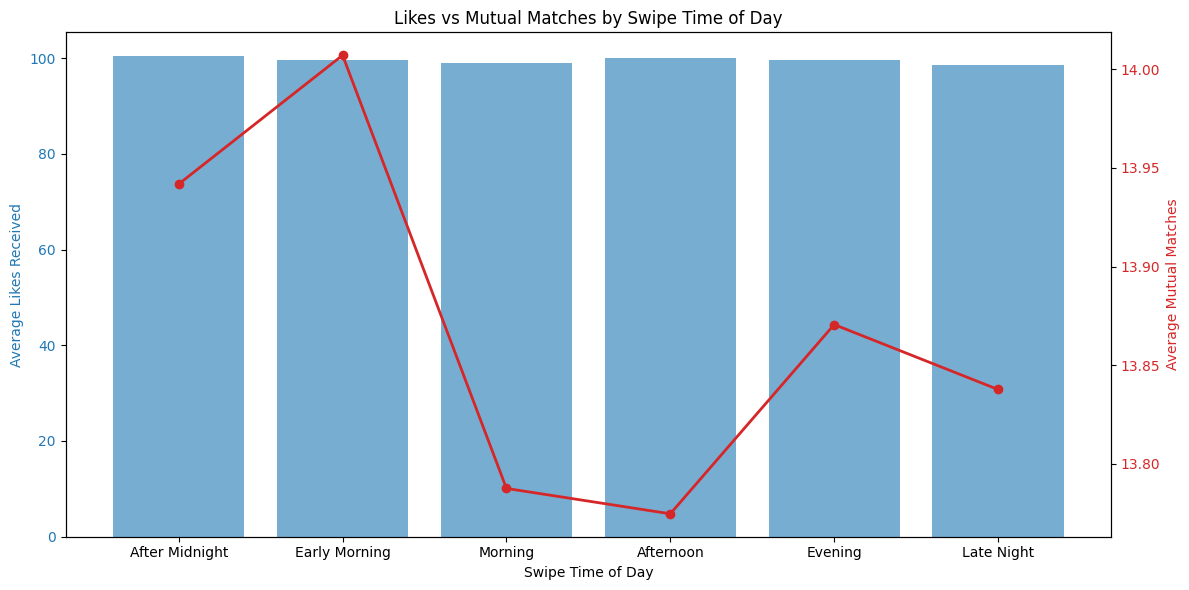

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Group data by swipe_time_of_day
grouped = df.groupby('swipe_time_of_day').agg({
    'likes_received': 'mean',
    'mutual_matches': 'mean'
}).reset_index()

# Sort the swipe_time_of_day logically
order = ['After Midnight', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Night']
grouped['swipe_time_of_day'] = pd.Categorical(grouped['swipe_time_of_day'], categories=order, ordered=True)
grouped = grouped.sort_values('swipe_time_of_day')

# Create plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot on primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Swipe Time of Day')
ax1.set_ylabel('Average Likes Received', color=color)
bars = ax1.bar(grouped['swipe_time_of_day'], grouped['likes_received'], color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Line plot on secondary y-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Mutual Matches', color=color)
line = ax2.plot(grouped['swipe_time_of_day'], grouped['mutual_matches'], color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

# Title and layout
plt.title('Likes vs Mutual Matches by Swipe Time of Day')
fig.tight_layout()
plt.show()


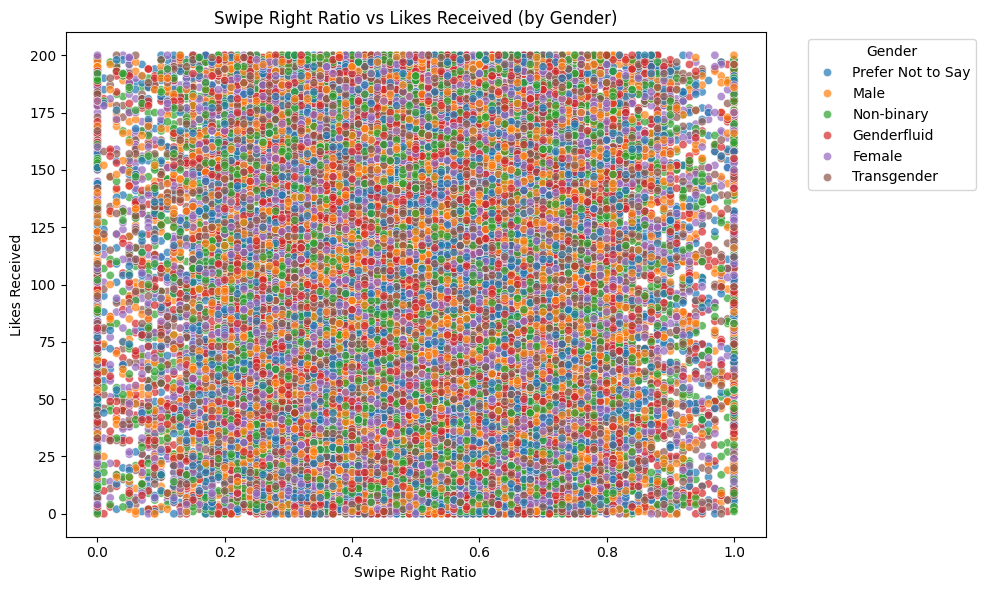

In [35]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='swipe_right_ratio', y='likes_received', hue='gender', alpha=0.7)
plt.title('Swipe Right Ratio vs Likes Received (by Gender)')
plt.xlabel('Swipe Right Ratio')
plt.ylabel('Likes Received')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<ipython-input-36-ee25f34ddf5c>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='education_level', y='message_sent_count', palette='Set3')


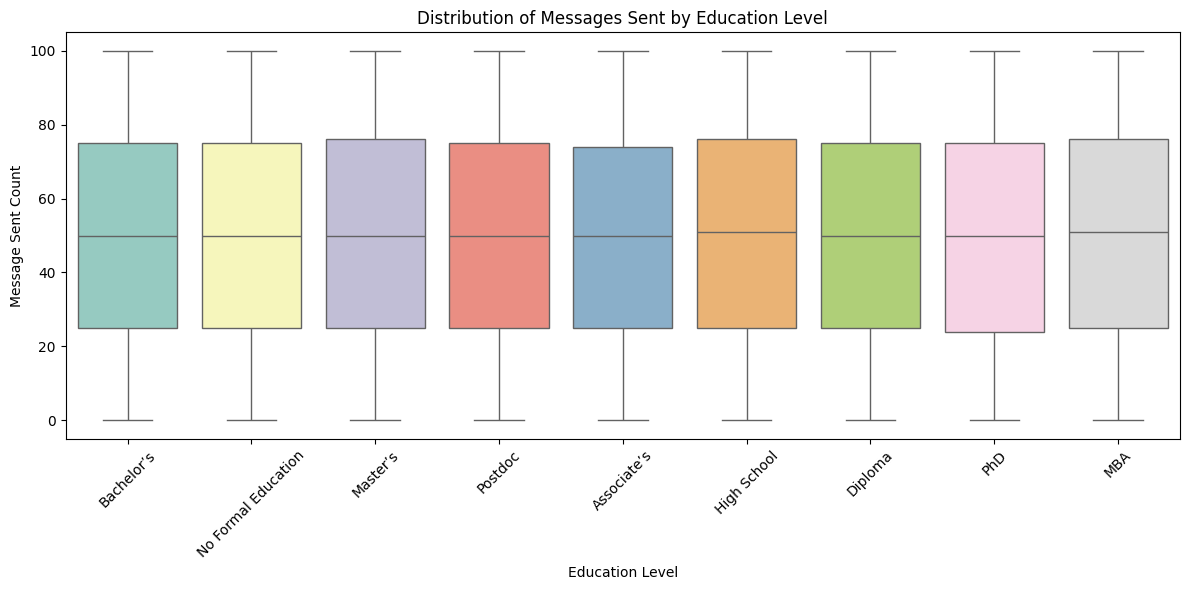

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='education_level', y='message_sent_count', palette='Set3')
plt.title('Distribution of Messages Sent by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Message Sent Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
